In [2]:
import matplotlib.colors as colors
from astropy.visualization import (MinMaxInterval, ZScaleInterval, LogStretch, SqrtStretch, LogStretch,
                                   ImageNormalize, PercentileInterval, AsinhStretch)

import astropy.units as u

from ISMgas.SupportingFunctions import plotWithError, load_pickle, save_spectra, airtovac, plotHistogram, cbarLegendPatch, printStats, createSubplotGrid, beautifyPlot
from ISMgas.spectra import AnalyzeSpectra 
from ISMgas.kcwi.kcwiFunctions import *
from ISMgas.visualization.fits import ScaleImage
from ISMgas.linelist import linelist_SDSS_emission
from ISMgas.kcwi.kcwiReduction import combineRedSide, reproject_and_mosaic, reproject_and_mosaic_cube, preprocess, preprocessCube


from scipy.optimize import curve_fit
from astropy.modeling import models, fitting
from astropy.constants import M_sun, m_p
import astropy.units as u



## This notebook runs through how to use ISMgas to align and combine multiple KCWI observation

NOTE: if you are using this to combine data from multiple nights, preprocess the datacubes such that they all have the same wavelength axis. The current code does not check this by default.

### Step 1 -- obtain the mosaic WCS from the median datacube frames


Set MJD-BEG to 60793.470972 from DATE-BEG.
Set MJD-END to 60793.486250 from DATE-END'. [astropy.wcs.wcs]
/home/keerthi/anaconda3/envs/ISMgas/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
Set MJD-BEG to 60793.486982 from DATE-BEG.
Set MJD-END to 60793.502260 from DATE-END'. [astropy.wcs.wcs]
/home/keerthi/anaconda3/envs/ISMgas/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


(None,)

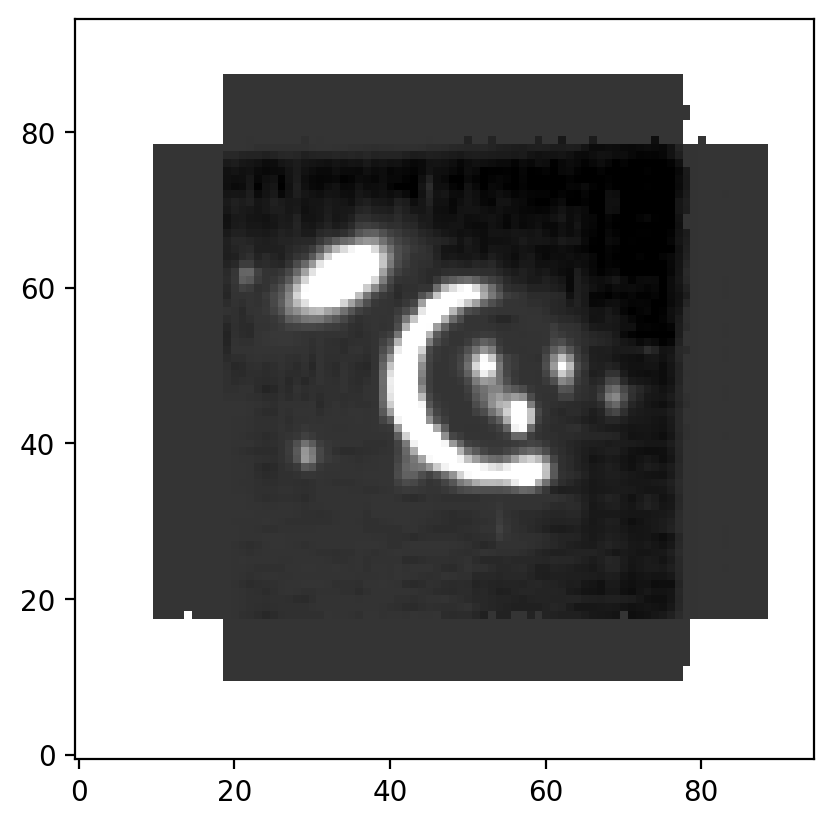

In [7]:

filenames = [

     "KB.20250428.42011.39_icubes.fits",
    "KB.20250428.43394.51_icubes.fits"
]

hdu1 = preprocess(filenames[0])
hdu2 = preprocess(filenames[1])


mosaic_data, mosaic_wcs = reproject_and_mosaic([hdu1,hdu2], method='interp')


plt.figure(dpi=200)

ScaleImage(mosaic_data).plot(),


### Step-2 : Reproject every datacube onto the same mosaic WCS

Use method='exact' for conserve the flux.

Set MJD-BEG to 60793.470972 from DATE-BEG.
Set MJD-END to 60793.486250 from DATE-END'. [astropy.wcs.wcs]
Set MJD-BEG to 60793.486982 from DATE-BEG.
Set MJD-END to 60793.502260 from DATE-END'. [astropy.wcs.wcs]
/home/keerthi/anaconda3/envs/ISMgas/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Computing shifts between datacubes...


/home/keerthi/anaconda3/envs/ISMgas/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/keerthi/anaconda3/envs/ISMgas/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Reprojecting slice 1/2597 of datacube-0...
Reprojecting slice 2/2597 of datacube-0...
Reprojecting slice 3/2597 of datacube-0...
Reprojecting slice 4/2597 of datacube-0...
Reprojecting slice 5/2597 of datacube-0...
Reprojecting slice 6/2597 of datacube-0...
Reprojecting slice 7/2597 of datacube-0...
Reprojecting slice 8/2597 of datacube-0...
Reprojecting slice 9/2597 of datacube-0...
Reprojecting slice 10/2597 of datacube-0...
Reprojecting slice 11/2597 of datacube-0...
Reprojecting slice 12/2597 of datacube-0...
Reprojecting slice 13/2597 of datacube-0...
Reprojecting slice 14/2597 of datacube-0...
Reprojecting slice 15/2597 of datacube-0...
Reprojecting slice 16/2597 of datacube-0...
Reprojecting slice 17/2597 of datacube-0...
Reprojecting slice 18/2597 of datacube-0...
Reprojecting slice 19/2597 of datacube-0...
Reprojecting slice 20/2597 of datacube-0...
Reprojecting slice 21/2597 of datacube-0...
Reprojecting slice 22/2597 of datacube-0...
Reprojecting slice 23/2597 of datacube-0.

/home/keerthi/anaconda3/envs/ISMgas/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


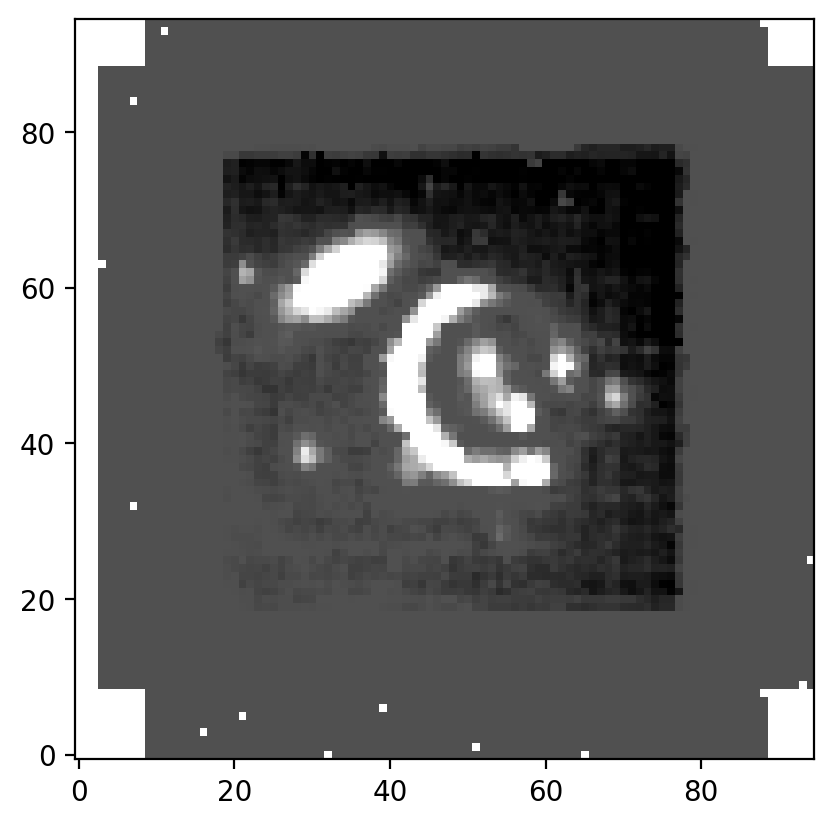

In [8]:

hdus = []
for filename in filenames: 
    hdus.append(preprocessCube(filename))
    
mosaic_data, mosaic_wcs = reproject_and_mosaic_cube(hdus, parallel=False, method='exact')

plt.figure(dpi=200)

ScaleImage(np.nanmedian(mosaic_data,axis=0)).plot()

## Save

In [11]:

hdu = fits.PrimaryHDU()
hdu.data = mosaic_data
hdu.header = mosaic_wcs.to_fits()[0].header
hdrFoo = fits.getheader(filenames[0])

hdu.header['CRVAL3'] = hdrFoo['CRVAL3']
hdu.header['CRPIX3'] = hdrFoo['CRPIX3']
hdu.header['CD3_3'] = hdrFoo['CD3_3']

hdu.writeto(f"AGEL162300_blue_combined.fits",overwrite=True)